# Figure Playground — Rubin Warning-Time Paper

Interactive sandbox for the paper figures. **Run the two setup cells once**, then run any
figure cell independently. Every figure cell starts with an `OPTIONS` block — flip a switch
(`STYLE = "bars"` → `"line"`) or un-comment an alternative line to iterate.

**Cohort conventions** (adopted 2026-07): prograde only (i < 90°); discovery statistics
include Sorcha-complete/pipeline-incomplete runs; IP-dependent statistics use
`status == "complete"` only. Full audit: `paper_claim_verification.ipynb`.

Data: `data/mar_run_analysis_20260301/summary_results.parquet` (committed on this branch).
The lead-time IP cell additionally needs `window_results.parquet` (72 MB, NOT in git — see
`figures_revised_20260706/README.md`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import sys

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
DATA = REPO / "data" / "mar_run_analysis_20260301"
sys.path.insert(0, str(REPO / "src"))
from adam_impact_study.types import ImpactorResultSummary

s = ImpactorResultSummary.from_parquet(DATA / "summary_results.parquet")
s = s.apply_mask(s.prograde_orbits())          # global prograde cohort
comp = s.apply_mask(s.complete())              # IP-dependent stats use this
print(f"prograde: {len(s):,} | prograde+complete: {len(comp):,}")

Matplotlib is building the font cache; this may take a moment.


prograde: 28,038 | prograde+complete: 27,893


In [2]:
# ---- shared arrays (prograde + complete, as the paper figures use) ----
diam = comp.orbit.diameter.to_numpy(zero_copy_only=False)
iy = np.array([t.datetime.year for t in comp.orbit.impact_time.to_astropy()])
disc = ~pc.is_null(comp.discovery_time.mjd()).to_numpy(zero_copy_only=False)
reached1 = ~pc.is_null(comp.ip_threshold_1_percent.mjd()).to_numpy(zero_copy_only=False)
obs = comp.observations.to_numpy(zero_copy_only=False)
max_ip = np.nan_to_num(comp.maximum_impact_probability.to_numpy(zero_copy_only=False), nan=0.0)
arc0 = pc.fill_null(comp.arc_length(), 0).to_numpy(zero_copy_only=False)
lead_days = pc.subtract(comp.orbit.impact_time.mjd(),
                        comp.discovery_time.mjd()).to_numpy(zero_copy_only=False)

diams = sorted(set(diam))
VIRIDIS = plt.cm.viridis(np.linspace(0, 1, len(diams)))

def get_bins(binning):
    """Return (labels, period_index) for 'decade' or '30yr' impact-period bins."""
    if binning == "30yr":
        edges = [2025, 2055, 2085, 2115, 2126]
        labels = ["2025-2054", "2055-2084", "2085-2114", "2115-2125"]
        return labels, np.digitize(iy, edges) - 1
    dec = (iy // 10) * 10
    uniq = sorted(set(dec))
    return [str(d) for d in uniq], np.array([uniq.index(d) for d in dec])

def bar_layout(NP):
    """Paper-style grouped-bar geometry: group positions and per-diameter offsets."""
    bar_w = 0.8 / len(diams) * 0.9
    xg = np.arange(NP) * 1.2
    offs = [(i - len(diams) / 2 + 0.5) * (bar_w * 1.1) for i in range(len(diams))]
    return xg, bar_w, offs

def finish(ax, labels, xticks, xlabel="Impact Decade"):
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)

print("helpers ready:", len(diams), "diameter bins", diams)

helpers ready: 6 diameter bins [np.float64(0.04), np.float64(0.08), np.float64(0.14), np.float64(0.25), np.float64(0.5), np.float64(1.0)]


## 1. Discovery-rate figure (current paper version)

Solid = discovered, hollow = observed-but-not-discovered. Alternatives from the iteration
history are in the OPTIONS block: the 3-category IP split, or line/step rendering.

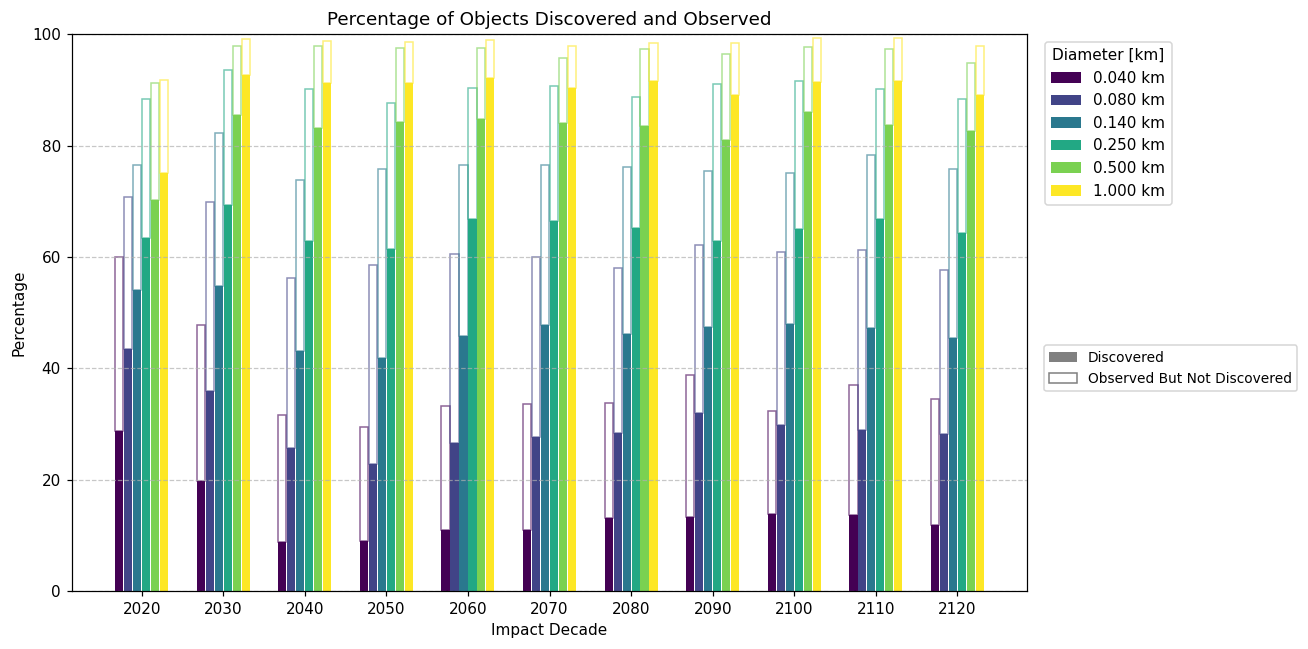

In [3]:
# ============ OPTIONS ============
BINNING = "decade"          # "decade" | "30yr"
STYLE = "bars"              # "bars" | "line" | "step"
SPLIT_BY_IP = False         # True -> solid: reached >=1% IP, faded: did not (3-category version)
# =================================

labels, period = get_bins(BINNING)
NP = len(labels)
xg, bar_w, offs = bar_layout(NP)
edges = np.arange(NP + 1, dtype=float)
centers = edges[:-1] + 0.5

fig, ax = plt.subplots(figsize=(12, 6), dpi=110)
for i, (d, c) in enumerate(zip(diams, VIRIDIS)):
    m = diam == d
    tot = np.array([(m & (period == p)).sum() for p in range(NP)], float)
    discovered = np.array([(m & (period == p) & disc).sum() for p in range(NP)]) / tot * 100
    hollow = np.array([(m & (period == p) & ~disc & (obs > 0)).sum() for p in range(NP)]) / tot * 100
    if STYLE == "bars":
        if SPLIT_BY_IP:
            solid = np.array([(m & (period == p) & disc & reached1).sum() for p in range(NP)]) / tot * 100
            faded = discovered - solid
            ax.bar(xg + offs[i], solid, width=bar_w, color=c, label=f"{d:.3f} km")
            ax.bar(xg + offs[i], faded, bottom=solid, width=bar_w, color=c, alpha=0.35)
            ax.bar(xg + offs[i], hollow, bottom=discovered, width=bar_w, edgecolor=c,
                   facecolor="none", alpha=0.6)
        else:
            ax.bar(xg + offs[i], discovered, width=bar_w, color=c, label=f"{d:.3f} km")
            ax.bar(xg + offs[i], hollow, bottom=discovered, width=bar_w, edgecolor=c,
                   facecolor="none", alpha=0.6)
    elif STYLE == "line":
        ax.plot(centers, discovered, "-o", color=c, ms=4, lw=1.8, label=f"{d:.3f} km")
        # ax.plot(centers, discovered + hollow, "--", color=c, lw=1.2)   # ever-observed total
    else:  # step
        ax.stairs(discovered, edges, color=c, lw=1.8, label=f"{d:.3f} km")

ticks = xg if STYLE == "bars" else centers
finish(ax, labels, ticks)
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.set_title("Percentage of Objects Discovered and Observed")
leg = ax.legend(title="Diameter [km]", frameon=True, bbox_to_anchor=(1.01, 1), loc="upper left")
if STYLE == "bars":
    ax.add_artist(leg)
    ph = [plt.Rectangle((0, 0), 1, 1, facecolor="gray", label="Discovered"),
          plt.Rectangle((0, 0), 1, 1, edgecolor="gray", facecolor="none",
                        label="Observed But Not Discovered")]
    if SPLIT_BY_IP:
        ph.insert(1, plt.Rectangle((0, 0), 1, 1, facecolor="gray", alpha=0.35,
                                   label="Discovered, did not reach 1% IP"))
    ax.legend(handles=ph, frameon=True, bbox_to_anchor=(1.01, 0.4), loc="center left", fontsize=9)
plt.tight_layout()
# fig.savefig("fig_discovery_status.png", bbox_inches="tight", dpi=300)
plt.show()

## 2. IAWN-threshold figure (current paper version)

% of *discovered* objects that never reach 1% IP, y capped at 60% (Braxton's request).

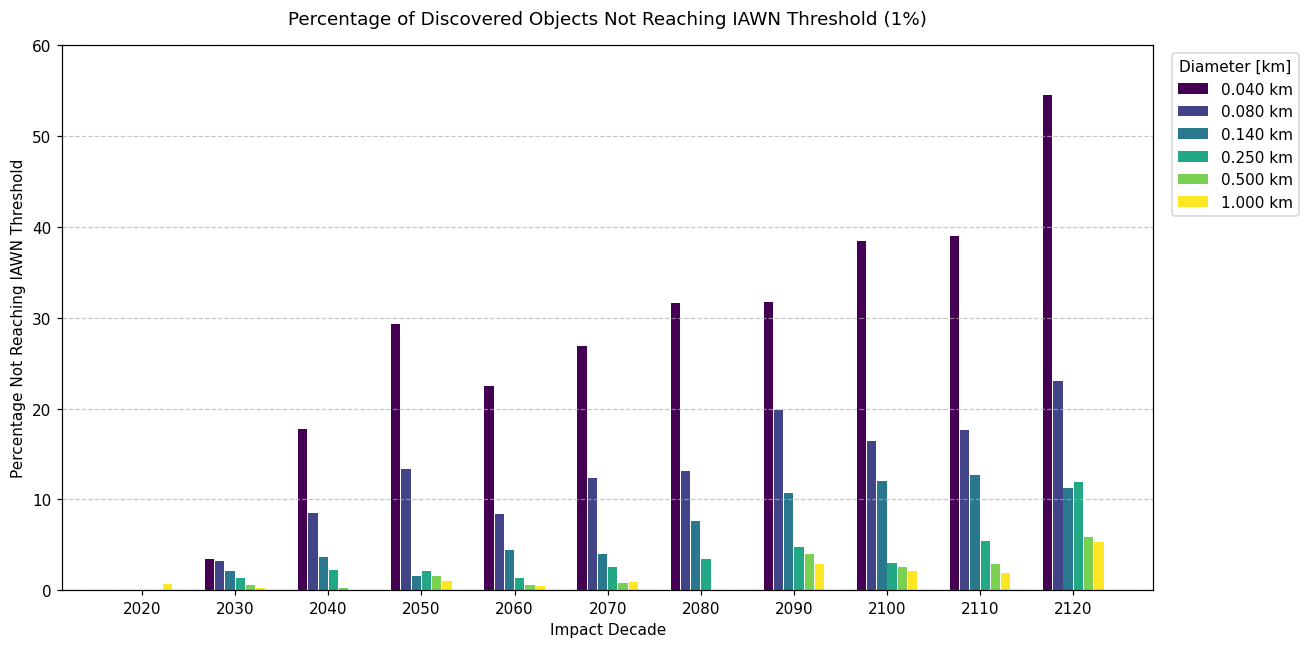

In [4]:
# ============ OPTIONS ============
BINNING = "decade"          # "decade" | "30yr"
STYLE = "bars"              # "bars" | "line" | "step"
YMAX = 60                   # 100 for the old full-range version
# =================================

labels, period = get_bins(BINNING)
NP = len(labels)
xg, bar_w, offs = bar_layout(NP)
edges = np.arange(NP + 1, dtype=float)
centers = edges[:-1] + 0.5

fig, ax = plt.subplots(figsize=(12, 6), dpi=110)
for i, (d, c) in enumerate(zip(diams, VIRIDIS)):
    m = (diam == d) & disc
    y = np.array([(~reached1[m & (period == p)]).mean() * 100 for p in range(NP)])
    if STYLE == "bars":
        ax.bar(xg + offs[i], y, width=bar_w, color=c, label=f"{d:.3f} km")
    elif STYLE == "line":
        ax.plot(centers, y, "-o", color=c, ms=4, lw=1.8, label=f"{d:.3f} km")
    else:
        ax.stairs(y, edges, color=c, lw=1.8, label=f"{d:.3f} km")

ticks = xg if STYLE == "bars" else centers
finish(ax, labels, ticks)
ax.set_ylabel("Percentage Not Reaching IAWN Threshold")
ax.set_ylim(0, YMAX)
ax.set_title("Percentage of Discovered Objects Not Reaching IAWN Threshold (1%)", pad=14)
ax.legend(title="Diameter [km]", frameon=True, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Combined 2×2

Panels: % discovered / panel B (configurable) / % never reaching 1% / mean arc length.
Panel B options cover the whole iteration history: obs-not-discovered, mean max IP,
median ± IQR, mean + IQR band.

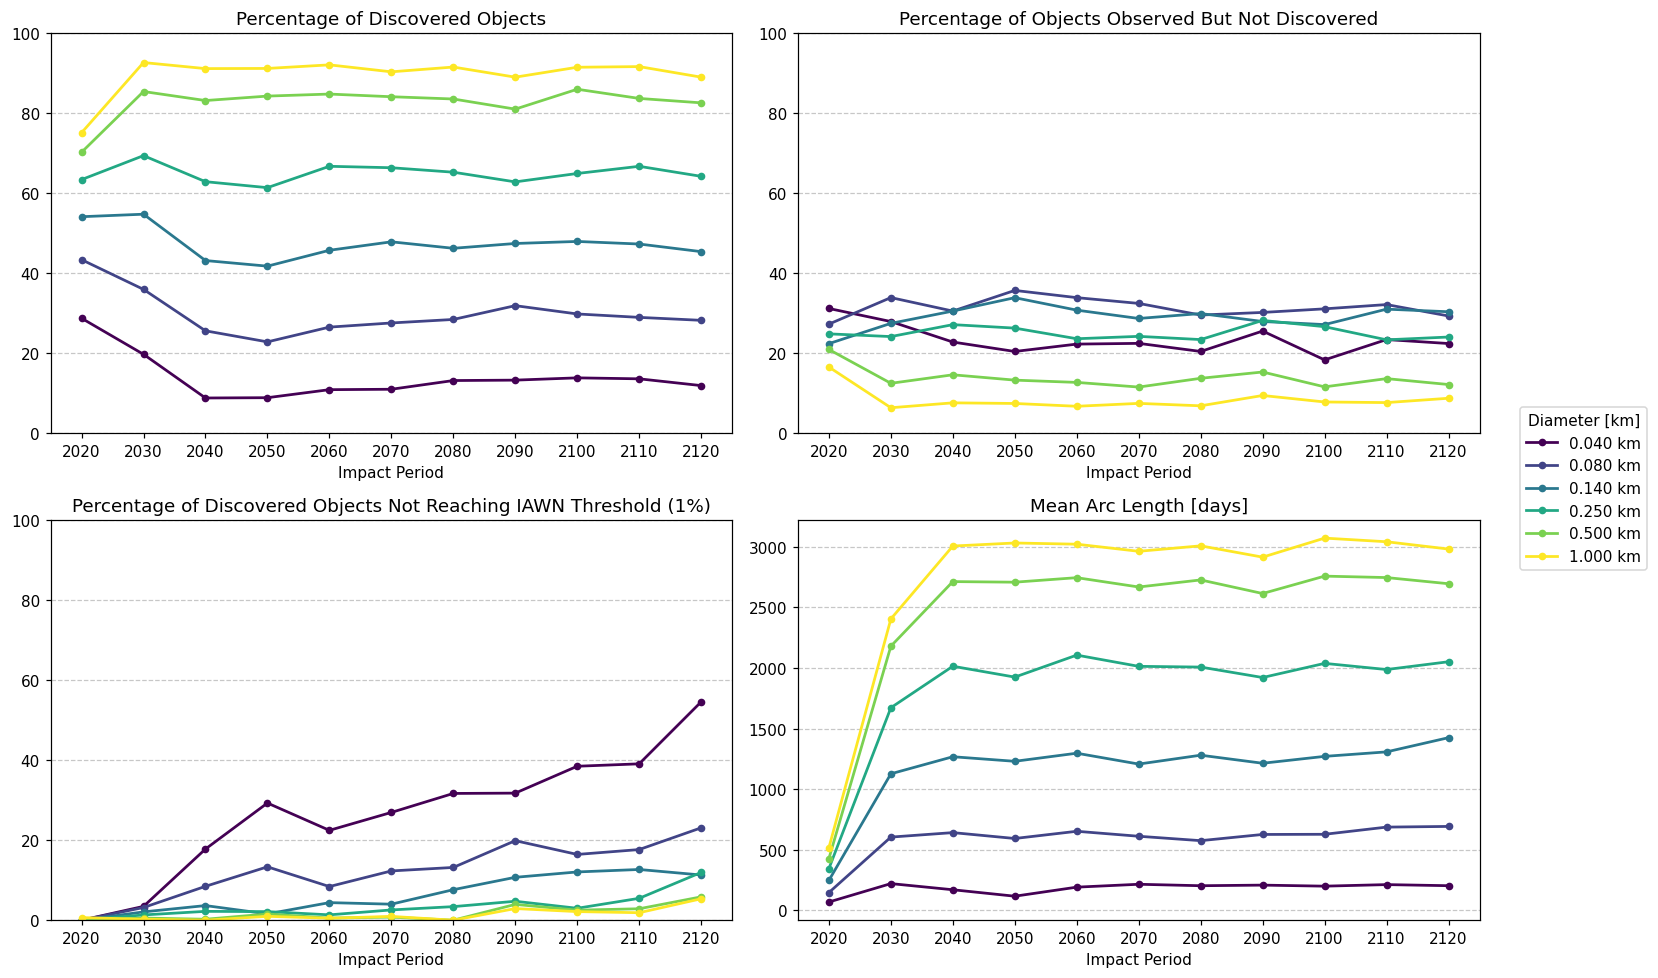

In [5]:
# ============ OPTIONS ============
BINNING = "decade"          # "decade" | "30yr"
STYLE = "line"              # "bars" | "line" | "step"
PANEL_B = "obs_not_disc"    # "obs_not_disc" | "mean_ip" | "median_iqr" | "mean_iqr"
# =================================

labels, period = get_bins(BINNING)
NP = len(labels)
xg, bar_w, offs = bar_layout(NP)
edges = np.arange(NP + 1, dtype=float)
centers = edges[:-1] + 0.5

fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=110)
axA, axB, axC, axD = axes.flat
for i, (d, c) in enumerate(zip(diams, VIRIDIS)):
    m = diam == d
    tot = np.array([(m & (period == p)).sum() for p in range(NP)], float)
    pA = np.array([(m & (period == p) & disc).sum() for p in range(NP)]) / tot * 100
    pB_obs = np.array([(m & (period == p) & ~disc & (obs > 0)).sum() for p in range(NP)]) / tot * 100
    ipsel = [max_ip[m & (period == p) & disc] for p in range(NP)]
    b_mean = np.array([np.nanmean(x) for x in ipsel])
    b_med = np.array([np.nanmedian(x) for x in ipsel])
    b_q25 = np.array([np.nanpercentile(x, 25) for x in ipsel])
    b_q75 = np.array([np.nanpercentile(x, 75) for x in ipsel])
    pC = np.array([(~reached1[m & (period == p) & disc]).mean() * 100 for p in range(NP)])
    pD = np.array([arc0[m & (period == p)].mean() for p in range(NP)])

    if PANEL_B == "obs_not_disc":
        yB, band = pB_obs, None
    elif PANEL_B == "mean_ip":
        yB, band = b_mean, None
    elif PANEL_B == "median_iqr":
        yB, band = b_med, (b_q25, b_q75)
    else:                                  # mean_iqr
        yB, band = b_mean, (b_q25, b_q75)

    for ax, y in ((axA, pA), (axB, yB), (axC, pC), (axD, pD)):
        if STYLE == "bars":
            ax.bar(xg + offs[i], y, width=bar_w, color=c, label=f"{d:.3f} km")
        elif STYLE == "line":
            ax.plot(centers, y, "-o", color=c, ms=4, lw=1.8, label=f"{d:.3f} km")
        else:
            ax.stairs(y, edges, color=c, lw=1.8, label=f"{d:.3f} km")
    if band is not None and STYLE == "line":
        axB.fill_between(centers, band[0], band[1], color=c, alpha=0.15, lw=0)
    elif band is not None and STYLE == "step":
        axB.stairs(band[1], edges, baseline=band[0], fill=True, color=c, alpha=0.15)

axA.set_title("Percentage of Discovered Objects"); axA.set_ylim(0, 100)
titles_b = {"obs_not_disc": "Percentage of Objects Observed But Not Discovered",
            "mean_ip": "Mean Maximum Impact Probability",
            "median_iqr": "Maximum Impact Probability (median ± IQR)",
            "mean_iqr": "Mean Maximum Impact Probability (shading: IQR)"}
axB.set_title(titles_b[PANEL_B])
axB.set_ylim(0, 100 if PANEL_B == "obs_not_disc" else 1.05)
axC.set_title("Percentage of Discovered Objects Not Reaching IAWN Threshold (1%)"); axC.set_ylim(0, 100)
axD.set_title("Mean Arc Length [days]")
ticks = xg if STYLE == "bars" else centers
for ax in axes.flat:
    finish(ax, labels, ticks, xlabel="Impact Period")
h, l = axA.get_legend_handles_labels()
fig.legend(h, l, title="Diameter [km]", loc="center left", bbox_to_anchor=(0.92, 0.5), frameon=True)
fig.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

## 4. IP-value figures (impact probability on the axis)

The max-IP distribution is **bimodal** (certify at ~1 or stall near 0) — log-y is what makes
it readable. Objects below the 10⁻⁴ Monte Carlo floor are drawn at the `<10⁻⁴` gutter.

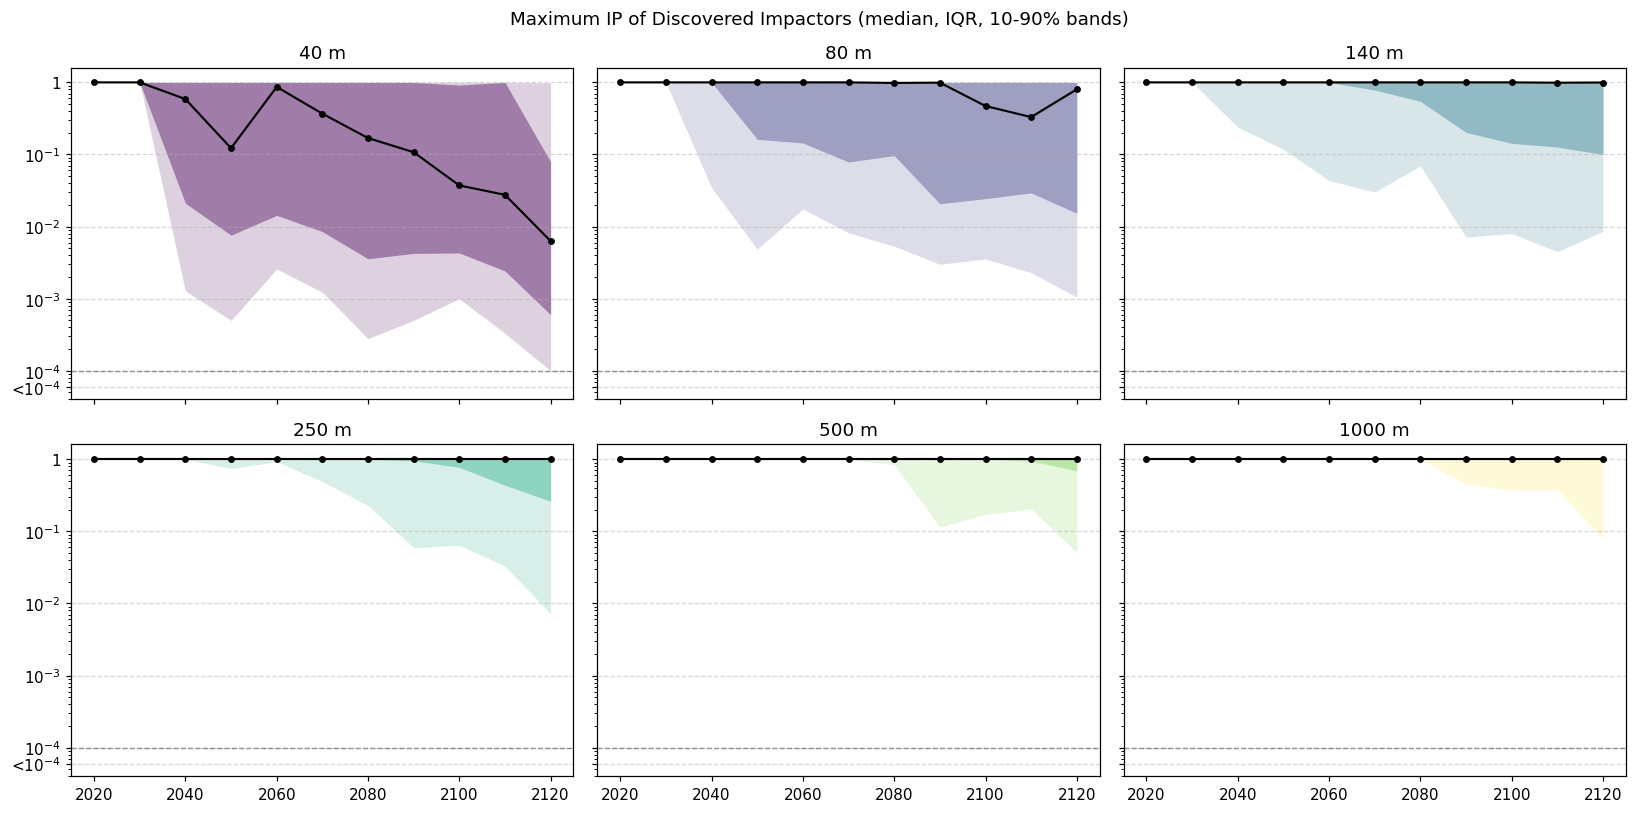

In [6]:
# ============ OPTIONS ============
MODE = "envelope"           # "envelope" | "boxplot" | "strip" | "range_bars"
BINNING = "decade"          # "decade" | "30yr"
PCT_BAND = (25, 75)         # band/box percentiles; try (10, 90)
STRIP_DIAMS = [0.04, 0.14, 1.0]   # diameters shown in strip mode
# =================================

FLOOR, DRAW_FLOOR = 1e-4, 6e-5
ip_c = np.where(max_ip < FLOOR, DRAW_FLOOR, max_ip)
labels, period = get_bins(BINNING)
NP = len(labels)
xg, bar_w, offs = bar_layout(NP)

def log_axis(ax):
    ax.set_yscale("log"); ax.set_ylim(4e-5, 1.6)
    ax.axhline(FLOOR, color="grey", lw=0.9, ls="--", zorder=0)
    ax.set_yticks([DRAW_FLOOR, 1e-4, 1e-3, 1e-2, 1e-1, 1])
    ax.set_yticklabels(["<10$^{-4}$", "10$^{-4}$", "10$^{-3}$", "10$^{-2}$", "10$^{-1}$", "1"])
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)

if MODE == "envelope":
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), dpi=110, sharex=True, sharey=True)
    xs = np.arange(NP)
    for ax, d, c in zip(axes.flat, diams, VIRIDIS):
        m = (diam == d) & disc
        q = {k: np.array([np.nanpercentile(ip_c[m & (period == p)], k) for p in range(NP)])
             for k in (10, PCT_BAND[0], 50, PCT_BAND[1], 90)}
        ax.fill_between(xs, q[10], q[90], color=c, alpha=0.18, lw=0)
        ax.fill_between(xs, q[PCT_BAND[0]], q[PCT_BAND[1]], color=c, alpha=0.4, lw=0)
        ax.plot(xs, q[50], "-o", color="black", ms=3.5, lw=1.4)
        ax.set_title(f"{d*1000:.0f} m"); log_axis(ax)
        ax.set_xticks(xs[::2]); ax.set_xticklabels(labels[::2])
    fig.suptitle("Maximum IP of Discovered Impactors (median, IQR, 10-90% bands)")
    fig.tight_layout()
elif MODE == "boxplot":
    fig, ax = plt.subplots(figsize=(13, 6.5), dpi=110)
    for i, (d, c) in enumerate(zip(diams, VIRIDIS)):
        data = [ip_c[(diam == d) & disc & (period == p)] for p in range(NP)]
        ax.boxplot(data, positions=xg + offs[i], widths=bar_w, whis=(5, 95), showfliers=False,
                   patch_artist=True, medianprops=dict(color="black"),
                   boxprops=dict(facecolor=c, lw=0.5), whiskerprops=dict(color=c), capprops=dict(color=c))
    finish(ax, labels, xg); log_axis(ax)
    ax.set_title("Maximum IP (box: IQR, whiskers: 5-95%)")
elif MODE == "strip":
    rng = np.random.default_rng(612)
    fig, ax = plt.subplots(figsize=(13, 6.5), dpi=110)
    o3 = np.linspace(-0.32, 0.32, len(STRIP_DIAMS))
    for d, o in zip(STRIP_DIAMS, o3):
        c = VIRIDIS[diams.index(d)]
        for p in range(NP):
            y = ip_c[(diam == d) & disc & (period == p)]
            ax.scatter(xg[p] + o + rng.uniform(-0.1, 0.1, len(y)), y, s=5, color=c,
                       alpha=0.25, linewidths=0, label=f"{d*1000:.0f} m" if p == 0 else None)
    finish(ax, labels, xg); log_axis(ax)
    ax.legend(markerscale=3); ax.set_title("Maximum IP of Every Discovered Impactor")
else:  # range_bars — linear axis, bars span PCT_BAND (the floating-bar version)
    fig, ax = plt.subplots(figsize=(12, 6), dpi=110)
    for i, (d, c) in enumerate(zip(diams, VIRIDIS)):
        m = (diam == d) & disc
        lo = np.array([np.nanpercentile(max_ip[m & (period == p)], PCT_BAND[0]) for p in range(NP)])
        hi = np.array([np.nanpercentile(max_ip[m & (period == p)], PCT_BAND[1]) for p in range(NP)])
        h = np.maximum(hi - lo, 0.012)
        ax.bar(xg + offs[i], h, bottom=np.minimum(lo, 1 - h), width=bar_w, color=c,
               label=f"{d:.3f} km")
    finish(ax, labels, xg); ax.set_ylim(0, 1.05)
    ax.set_title(f"Maximum IP range ({PCT_BAND[0]}th-{PCT_BAND[1]}th percentile)")
    ax.legend(title="Diameter [km]", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

## 5. IP outcome-mix figures (fractions crossing thresholds)

The threshold-fraction alternatives: stacked outcome bands, certified-fraction lines,
or the annotated heatmap.

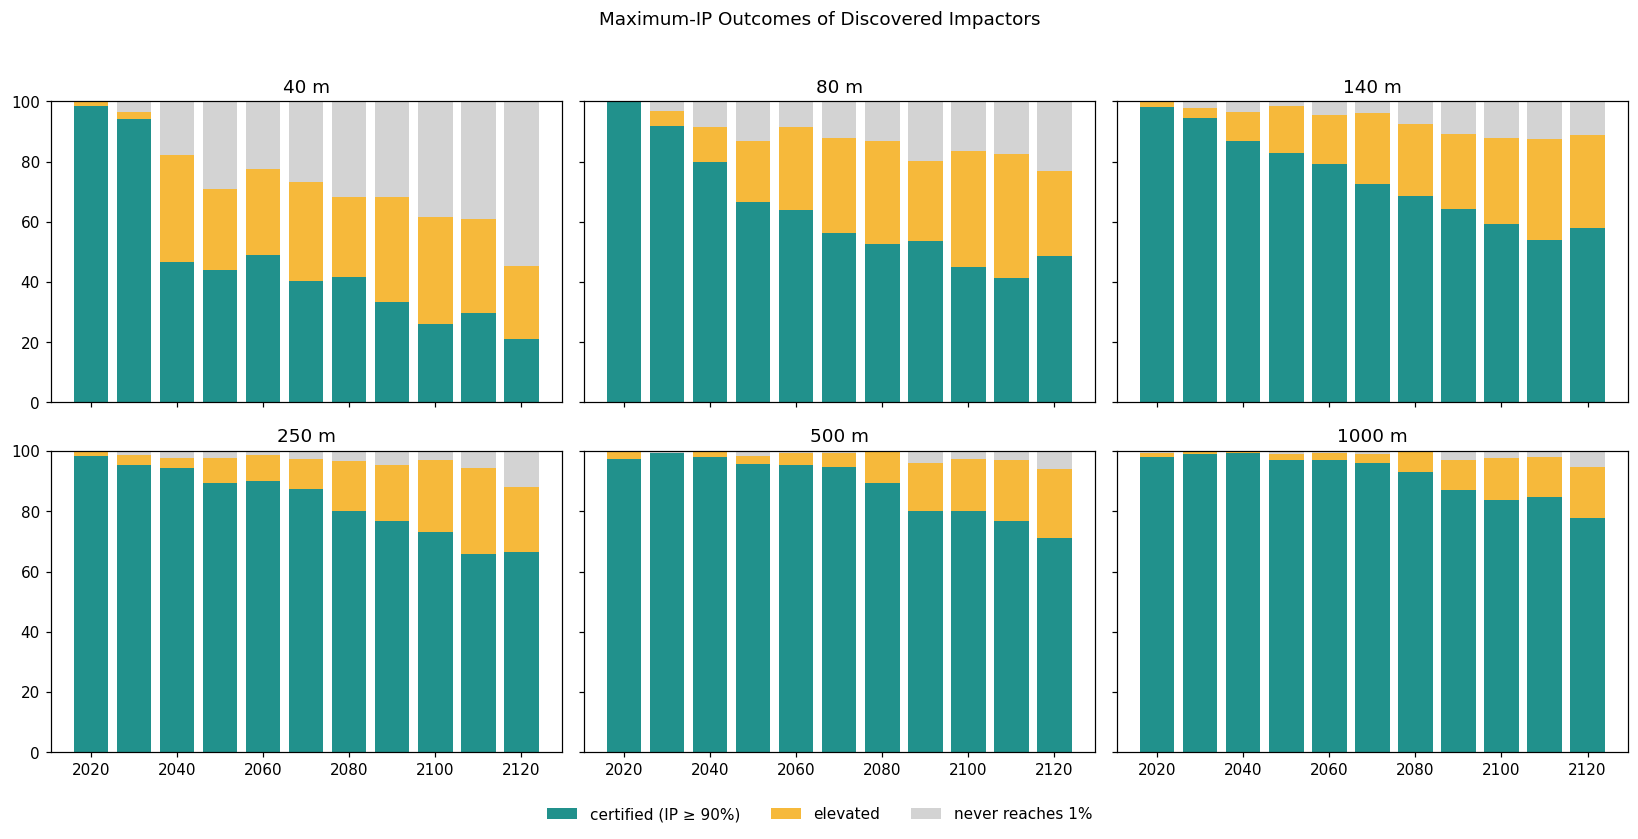

In [7]:
# ============ OPTIONS ============
MODE = "stack"              # "stack" | "lines" | "heatmap"
BINNING = "decade"
CERT, ELEV = 0.90, 0.01     # certified / elevated thresholds
# =================================

labels, period = get_bins(BINNING)
NP = len(labels)
xs = np.arange(NP)
fc, fe, fl = {}, {}, {}
for d in diams:
    m = (diam == d) & disc
    x = [max_ip[m & (period == p)] for p in range(NP)]
    fc[d] = np.array([(xi >= CERT).mean() * 100 for xi in x])
    fe[d] = np.array([((xi >= ELEV) & (xi < CERT)).mean() * 100 for xi in x])
    fl[d] = np.array([(xi < ELEV).mean() * 100 for xi in x])

if MODE == "stack":
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), dpi=110, sharex=True, sharey=True)
    for ax, d in zip(axes.flat, diams):
        ax.bar(xs, fc[d], color="#21918c", width=0.8, label=f"certified (IP ≥ {CERT:.0%})")
        ax.bar(xs, fe[d], bottom=fc[d], color="#f6b93b", width=0.8, label="elevated")
        ax.bar(xs, fl[d], bottom=fc[d] + fe[d], color="#d3d3d3", width=0.8,
               label=f"never reaches {ELEV:.0%}")
        ax.set_title(f"{d*1000:.0f} m"); ax.set_ylim(0, 100)
        ax.set_xticks(xs[::2]); ax.set_xticklabels(labels[::2])
    h, l = axes.flat[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Maximum-IP Outcomes of Discovered Impactors")
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])
elif MODE == "lines":
    fig, ax = plt.subplots(figsize=(11, 6), dpi=110)
    for d, c in zip(diams, VIRIDIS):
        ax.plot(xs, fc[d], "-o", color=c, ms=4.5, lw=1.9, label=f"{d:.3f} km")
        ax.plot(xs, fc[d] + fe[d], "--", color=c, lw=1.3)
    finish(ax, labels, xs); ax.set_ylim(0, 102)
    ax.set_title(f"Reaching IP ≥ {CERT:.0%} (solid) and ≥ {ELEV:.0%} (dashed)")
    ax.legend(title="Diameter [km]", bbox_to_anchor=(1.01, 1), loc="upper left")
else:  # heatmap
    grid = np.array([fc[d] for d in diams])
    fig, ax = plt.subplots(figsize=(11, 5), dpi=110)
    im = ax.imshow(grid, aspect="auto", cmap="viridis", vmin=0, vmax=100, origin="lower")
    ax.set_xticks(xs); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(diams))); ax.set_yticklabels([f"{d*1000:.0f} m" for d in diams])
    for r in range(len(diams)):
        for cx in range(NP):
            ax.text(cx, r, f"{grid[r, cx]:.0f}", ha="center", va="center", fontsize=8.5,
                    color="white" if grid[r, cx] < 55 else "black")
    fig.colorbar(im, ax=ax, label=f"% reaching IP ≥ {CERT:.0%}")
    ax.set_title(f"Percentage of Discovered Impactors Reaching IP ≥ {CERT:.0%}")
plt.show()

## 6. IP distribution N years before impact

Needs `window_results.parquet` (not committed — 72 MB). The cell skips gracefully if
the file is absent. Styles: filled histogram / step ("the line following the histogram
tops") / plain line.

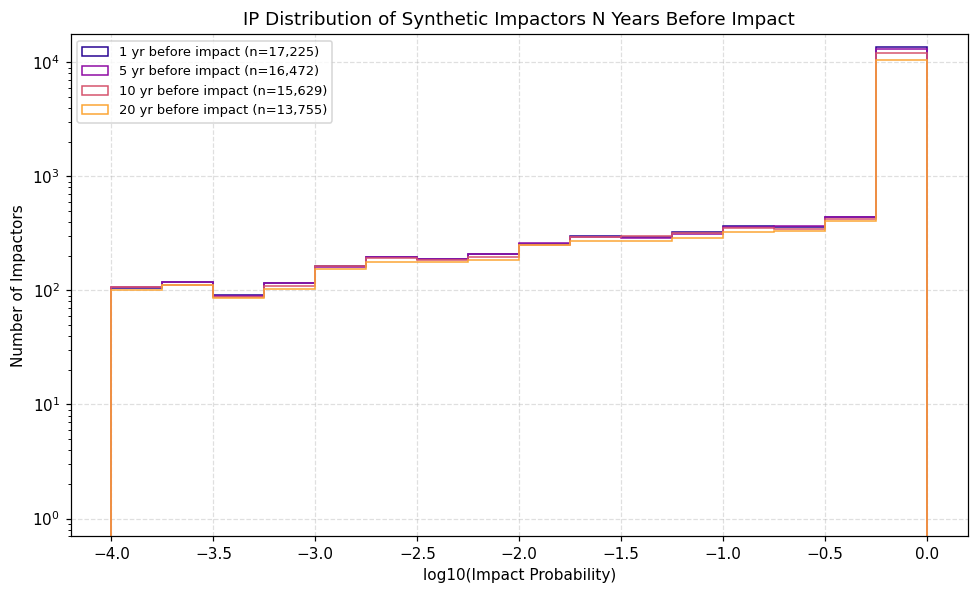

In [8]:
# ============ OPTIONS ============
STYLE = "step"              # "step" | "filled" | "line"
LEADS = [1, 5, 10, 20]      # years before impact
LOG_Y = True                # False -> linear (the IP≈1 spike dominates)
# =================================

wr_path = DATA / "window_results.parquet"
if not wr_path.exists():
    print("window_results.parquet not found - copy it from the original machine to run this cell")
else:
    wr = pq.read_table(wr_path, columns=["orbit_id", "observation_end", "impact_probability"])
    wdf = pd.DataFrame({
        "orbit_id": wr["orbit_id"].to_pandas(),
        "end_days": pc.struct_field(wr["observation_end"], "days").to_pandas().astype(float),
        "ip": wr["impact_probability"].to_pandas(),
    }).dropna(subset=["end_days"])
    oid = np.array(comp.orbit.orbit_id.to_pylist())
    imp_mjd = comp.orbit.impact_time.mjd().to_numpy(zero_copy_only=False)
    imp_map = pd.Series(imp_mjd, index=oid)
    wdf = wdf[wdf.orbit_id.isin(imp_map.index)]
    wdf["lead_yr"] = (wdf.orbit_id.map(imp_map) - wdf.end_days) / 365.25
    wdf = wdf.sort_values(["orbit_id", "end_days"])

    bins = np.arange(-4.0, 0.01, 0.25)
    cbin = (bins[:-1] + bins[1:]) / 2
    lead_colors = plt.cm.plasma(np.linspace(0.05, 0.8, len(LEADS)))
    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=110)
    for xyr, c in zip(LEADS, lead_colors):
        sel = wdf[wdf.lead_yr >= xyr].groupby("orbit_id").last()
        pos = sel.ip.dropna(); pos = pos[pos > 0]
        h, _ = np.histogram(np.log10(np.clip(pos, 1e-4, 1.0)), bins=bins)
        lbl = f"{xyr} yr before impact (n={len(pos):,})"
        if STYLE == "filled":
            ax.hist(cbin, bins=bins, weights=h, alpha=0.35, color=c, label=lbl)
        elif STYLE == "step":
            ax.hist(cbin, bins=bins, weights=h, histtype="step", lw=1.8, color=c, label=lbl)
        else:
            ax.plot(cbin, h, "-", lw=1.8, color=c, label=lbl)
    ax.set_xlabel("log10(Impact Probability)")
    ax.set_ylabel("Number of Impactors")
    if LOG_Y:
        ax.set_yscale("log"); ax.set_ylim(0.7, None)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8.5, loc="upper left")
    ax.set_title("IP Distribution of Synthetic Impactors N Years Before Impact")
    plt.tight_layout()
    plt.show()